In [56]:
library(tidyverse)
library(dplyr)
library(ggplot2)
library(vegan)
library(ggstatsplot)
library(cowplot)
library(ggpubr)

# File ordering================================================================================================================================

In [57]:
taxa_tab <- read.table("/ceph//projects/010_SweMaMi/bm.nowak/data/tp1_taxa_fp_sp__50_250822.tsv", header = TRUE, sep ="\t", check.names = FALSE, quote='"') 
head(taxa_tab)

,100000115046,100000133514,100000138427,100000416914,100000416341,100000417300,100000141564,100000112861,100000116982,100000117590,⋯,100000404683,100000410189,100000180006,100000410554,100000422410,100000424421,100000167687,100000422946,100000165058,100000419175
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Coprococcus eutactus,1.92768,0.15521,0.05160,0.02486,6.62230,0.30236,2.25139,0.00000,0.00000,0.42317,⋯,0.16779,2.72513,0.00000,0.93544,0.00000,4.42402,0.00000,4.46554,0.00000,0.00000
Faecalibacterium prausnitzii,3.20883,4.32581,4.53698,3.39437,3.26358,7.13674,4.51069,7.70578,4.33970,0.19672,⋯,2.84157,3.24886,5.24076,1.91233,6.89058,7.44669,2.90277,6.99612,6.78398,7.72660
Ruminococcus bromii,12.75072,0.84583,5.68254,2.92580,0.00044,4.13723,5.12663,4.96465,1.35757,8.26843,⋯,4.74826,12.33869,7.39686,0.00842,0.00135,1.89198,7.79235,0.00361,13.89218,0.00000
Ruminococcus bicirculans,0.64417,0.04445,2.55341,0.11893,0.09988,1.25623,1.32888,0.00064,4.66429,0.70478,⋯,0.19760,0.28484,0.00000,0.01427,0.10956,1.09689,0.10850,3.50633,0.00000,0.00000
Eubacterium rectale,0.95028,1.20350,5.57078,0.13382,2.26475,3.46031,0.59886,0.63884,2.51539,0.09724,⋯,0.12479,3.22173,1.25968,0.10241,4.25136,1.03758,21.90512,0.20310,2.13466,8.66076
Phocaeicola vulgatus,1.31137,1.54361,0.37413,0.28747,0.96566,2.37364,2.17415,3.13447,0.00000,2.93263,⋯,2.52242,2.21001,5.07246,3.08527,2.57127,1.68231,0.00026,3.65610,4.75778,4.36198


In [58]:
colnames(taxa_tab)

[1] "100000115046" "100000133514" "100000138427" "100000416914" "100000416341"
 [6] "100000417300" "100000141564" "100000112861" "100000116982" "100000117590"
[11] "100000126486" "100000114162" "100000110713" "100000108109" "100000103241"
[16] "100000101469" "100000415924" "100000417676" "100000402412" "100000401705"
[21] "100000401859" "100000424865" "100000193464" "100000157404" "100000128343"
[26] "100000101674" "100000101155" "100000102589" "100000114025" "100000158999"
[31] "100000101841" "100000148624" "100000102794" "100000129906" "100000136621"
[36] "100000124499" "100000419489" "100000429136" "100000417447" "100000401965"
[41] "100000404683" "100000410189" "100000180006" "100000410554" "100000422410"
[46] "100000424421" "100000167687" "100000422946" "100000165058" "100000419175"

In [59]:
taxa_tab[,1]

[1]  1.92768  3.20883 12.75072  0.64417  0.95028  1.31137  1.09072  0.27629
  [9]  2.24122  0.00000  0.00000  0.00000  2.52593  1.75332  0.93406  1.51821
 [17]  0.57943  1.87246  0.47620  0.53308  0.00000  0.01418  0.77935  1.93256
 [25]  0.09474  0.66964  1.00237  0.58479  1.12836  0.44795  0.07149  0.60658
 [33]  0.24541  0.36206  0.00000  0.40623  0.44727  0.13883  0.00000  0.00000
 [41]  0.30232  0.00823  0.00000  3.52266  0.26468  0.46706  0.15246  0.53333
 [49]  0.16055  0.06101  0.10488  0.01344  0.18417  0.24924  0.44037  0.00000
 [57]  0.09464  0.00000  0.00000  0.12919  0.25350  0.05122  0.01220  0.17460
 [65]  0.33826  0.63592  0.17338  0.19604  0.11116  0.09649  0.00000  0.00000
 [73]  0.55267  0.91567  0.90100  0.14455  0.27360  0.03501  0.08576  0.00000
 [81]  0.00843  0.47442  0.00659  0.22679  0.24442  0.17284  0.00785  0.00764
 [89]  0.00000  0.00000  0.04528  0.11533  0.70758  0.03964  0.00000  0.10336
 [97]  0.20686  0.05096  0.68265  0.87287  0.06382  0.55525  0.06119  0.00000
[105]  0.01462  0.00000  0.00000  0.20754  0.39751  0.11420  0.00203  0.01281
[113]  0.39001  0.19615  0.00210  0.05501  0.00000  0.00000  0.00000  0.00000
[121]  0.01828  0.09674  0.01924  0.05677  0.45188  0.22052  0.04047  0.06329
[129]  0.01164  0.00000  0.00151  1.03222  0.00000  0.11058  0.00000  0.27612
[137]  0.00000  0.00980  0.00867  0.00000  0.00000  0.02419  0.09819  0.00000
[145]  0.02649  0.00000  0.13850  0.00000  0.11731  0.00760  0.00433  0.53331
[153]  0.02778  0.01947  0.00000  0.13499  0.01156  0.32244  0.00000  0.03771
[161]  0.03226  0.00000  0.00000  0.00000  0.58217  0.01691  0.00000  0.00000
[169]  0.02987  0.02696  0.03105  0.00517  0.02339  0.00000  0.00320  0.01116
[177]  0.05235  0.00000  0.41285  0.02262  0.13884  0.00418  0.00000  0.00321
[185]  0.00000  1.26094  0.07219  0.00427  0.35658  0.06629  0.00000  0.08985
[193]  0.03710  0.02060  0.50113  0.60669  0.02181  0.00000  0.04530  0.06454
[201]  0.00417  0.00000  0.00000  0.04188  0.03139  0.00665  0.00000  0.00000
[209]  0.04176  0.00000  0.01470  0.00000  0.00920  0.04365  0.03356  0.00000
[217]  0.00137  0.00112  0.03669  0.00000  0.01631  0.06524  0.02436  0.00646
[225]  0.00000  0.06601  0.21153  0.11765  0.00299  0.00000  0.00062  0.00332
[233]  0.00000  2.53829  0.19914  0.00023  0.01867  0.00000  0.00256  0.00784
[241]  0.00000  0.00598  0.00343  0.00000  0.00602  0.00000  0.00246  0.00000
[249]  0.00034  0.00065  0.00000  0.00032  0.01186  0.00000  0.03982  0.02831
[257]  0.00404  0.00348  0.00000  0.00261  0.01073  0.00000  0.00000  0.00000
[265]  0.00000  0.00000  0.01266  0.00684  0.00025  0.37091  0.00000  0.00185
[273]  0.01057  0.22110  0.00509  0.00000  0.00000  0.03213  0.02145  0.00310
[281]  0.00000  0.00000  0.02505  0.03966  0.00000  0.00000  0.00000  0.00693
[289]  0.00000  0.00000  0.55409  0.00000  0.00000  0.00000  0.00220  0.00104
[297]  0.00000  0.00000  0.00478  0.00180  0.00122  0.00062  0.00620  0.00000
[305]  0.00000  0.00224  0.00000  0.00000  0.00128  0.00475  0.00000  0.00533
[313]  0.00306  0.00112  0.00000  0.00000  0.47524  0.00000  0.00879  0.08567
[321]  0.00166  0.00000  0.00000  0.00074  0.00222  0.00000  0.00000  0.00275
[329]  0.00000  0.04748  0.00022  0.00000  0.62936  0.00000  0.00014  0.00358
[337]  0.00000  0.00000  0.00000  0.00000  0.00000  0.00149  0.03199  0.26986
[345]  0.00000  0.00000  0.00000  0.00000  0.00161  0.00000  0.00000  0.00235
[353]  0.00000  0.00000  0.00387  0.00233  0.00296  0.00168  0.00000  0.00000
[361]  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000  0.00000
[369]  0.00694  0.00000  0.00080  0.00000  0.00121  0.00000  0.00000  0.00000
[377]  0.00000  0.00000  0.00194  0.00082  0.00089  0.00000  0.00000  0.00662
[385]  0.00000  0.00000  0.00000  0.00402  0.00000  0.00000  0.00224  0.00000
[393]  0.00655  0.00000  0.00000  0.00000  0.01078  0.00000  0.00000  0.00000
[401]  0.00000  0.00000  0.00000  0.00000  0.00000  0.00080  0.00000  0.00000
[409]  0.00000  0.00000 

In [60]:
row.names(taxa_tab)

[1] "Coprococcus eutactus"                                          
  [2] "Faecalibacterium prausnitzii"                                  
  [3] "Ruminococcus bromii"                                           
  [4] "Ruminococcus bicirculans"                                      
  [5] "Eubacterium rectale"                                           
  [6] "Phocaeicola vulgatus"                                          
  [7] "Candidatus Cibionibacter_quicibialis"                          
  [8] "Lachnospira pectinoschiza"                                     
  [9] "Clostridium sp_AF34_10BH"                                      
 [10] "Catenibacterium SGB4425"                                       
 [11] "Phocaeicola plebeius"                                          
 [12] "Holdemanella biformis"                                         
 [13] "Roseburia faecis"                                              
 [14] "Fusicatenibacter saccharivorans"                               
 [15] "Blautia wexlerae"                                              
 [16] "GGB3256 SGB4303"                                               
 [17] "Faecalibacterium SGB15346"                                     
 [18] "Bacteroides uniformis"                                         
 [19] "Ruminococcus torques"                                          
 [20] "Collinsella aerofaciens"                                       
 [21] "Bifidobacterium pseudocatenulatum"                             
 [22] "Clostridium sp_AM49_4BH"                                       
 [23] "Blautia massiliensis"                                          
 [24] "Anaerostipes hadrus"                                           
 [25] "Roseburia intestinalis"                                        
 [26] "Clostridiales bacterium_KLE1615"                               
 [27] "Dorea longicatena"                                             
 [28] "Alistipes putredinis"                                          
 [29] "Bifidobacterium adolescentis"                                  
 [30] "Roseburia sp_AF02_12"                                          
 [31] "Faecalicatena fissicatena"                                     
 [32] "Bifidobacterium longum"                                        
 [33] "Anaerobutyricum hallii"                                        
 [34] "Clostridiaceae bacterium_Marseille_Q4149"                      
 [35] "Phocaeicola massiliensis"                                      
 [36] "GGB6612 SGB9346"                                               
 [37] "Blautia obeum"                                                 
 [38] "Coprococcus comes"                                             
 [39] "Phascolarctobacterium succinatutens"                           
 [40] "GGB34797 SGB14322"                                             
 [41] "Clostridium sp_AF36_4"                                         
 [42] "GGB3746 SGB5089"                                               
 [43] "Ruminococcus callidus"                                         
 [44] "GGB9635 SGB15106"                                              
 [45] "Coprococcus catus"                                             
 [46] "Sutterella wadsworthensis"                                     
 [47] "Bacteroides stercoris"                                         
 [48] "Oscillibacter sp_ER4"                                          
 [49] "Parabacteroides merdae"                                        
 [50] "Paraprevotella clara"                                          
 [51] "Firmicutes bacterium_AF16_15"                                  
 [52] "Blautia luti"                                                  
 [53] "Dorea formicigenerans"                                         
 [54] "GGB9708 SGB15234"                                              
 [55] "Lacrimispora celerecrescens"                                   
 [56] "Ruminococcus sp_BSD2780120874_150323_B10"                      
 [57] "Blautia glucerasea"

In [61]:
combined_fp_sp_tp1 <- read.csv("/ceph/projects//010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/2025-08-01_combined_fp_sp_tp1.csv", header = TRUE)

In [62]:
fp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/2025-08-01fp_tp1_filt_nulliparous.csv", header = TRUE)
dim(fp_tp1)
head(fp_tp1)

[1]  25 566

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<chr>,<int>,<int>
1,5367,S194e21b,NA,0,0,0,2018-11-16,P159f9c8,0,36,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
2,5297,S1a267fa,NA,0,0,0,2019-05-23,P1a267fa,0,32,⋯,0,NA,NA,NA,NA,38,Spontaneous,NA,NA,0
3,5208,Sa8397fa,NA,0,0,0,2018-03-14,P1ef420d,0,27,⋯,0,NA,NA,NA,NA,28,Spontaneous,very_w28_31,1,0
4,5301,S1f862a6,NA,0,0,0,2018-03-07,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,31,Spontaneous,very_w28_31,1,0
5,5285,S3c0f6ee,NA,0,0,0,2019-03-25,P3c0f6ee,0,31,⋯,0,NA,NA,NA,NA,38,Spontaneous,NA,NA,0
6,5275,S2b86cc0,NA,0,0,0,2019-05-29,P3cac7b0,0,31,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0


In [63]:
sp_tp1 <- read.csv("/ceph/projects/010_SweMaMi/bm.nowak/filtered_data/feacal/tp1_nulliparous/2025-08-01sp_tp1_filt_nulliparous.csv", header = TRUE)
dim(sp_tp1)
head(sp_tp1)

[1]  25 566

,X,Studienummer,Correct_PN,Prev_RPL,Prev_IUFD,Prev_miscarriage_numb,Q1_Datum,Q1_Personnummer,Avbruten_graviditet,age_checked,⋯,diffdays,missfall.IUFD_week,IUFD,missfall,missfall.IUFD_comments,Gest_w_combined,deliv_start_combined,Type_of_PTB,s_PTB,preeclampsia_epi_analysis
,<int>,<chr>,<lgl>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,⋯,<int>,<lgl>,<lgl>,<lgl>,<lgl>,<int>,<chr>,<lgl>,<lgl>,<int>
1,5391,S159f9c8,NA,0,0,0,2021-01-28,P159f9c8,0,38,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
2,5332,Sb124b17,NA,0,0,2,2021-01-06,P1a267fa,0,34,⋯,0,NA,NA,NA,NA,41,Spontaneous,NA,NA,0
3,5247,S1ef420d,NA,0,0,1,2020-09-17,P1ef420d,0,30,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0
4,5305,Sa79a719,NA,0,0,1,2019-01-17,P1f862a6,0,32,⋯,0,NA,NA,NA,NA,41,Induction,NA,NA,0
5,5310,S5097402,NA,0,0,1,2020-10-18,P3c0f6ee,0,33,⋯,0,NA,NA,NA,NA,39,Spontaneous,NA,NA,0
6,5311,S3cac7b0,NA,0,0,0,2020-10-20,P3cac7b0,0,33,⋯,0,NA,NA,NA,NA,40,Spontaneous,NA,NA,0


In [64]:
dim(taxa_tab)
head(taxa_tab)

[1] 984  50

,100000115046,100000133514,100000138427,100000416914,100000416341,100000417300,100000141564,100000112861,100000116982,100000117590,⋯,100000404683,100000410189,100000180006,100000410554,100000422410,100000424421,100000167687,100000422946,100000165058,100000419175
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Coprococcus eutactus,1.92768,0.15521,0.05160,0.02486,6.62230,0.30236,2.25139,0.00000,0.00000,0.42317,⋯,0.16779,2.72513,0.00000,0.93544,0.00000,4.42402,0.00000,4.46554,0.00000,0.00000
Faecalibacterium prausnitzii,3.20883,4.32581,4.53698,3.39437,3.26358,7.13674,4.51069,7.70578,4.33970,0.19672,⋯,2.84157,3.24886,5.24076,1.91233,6.89058,7.44669,2.90277,6.99612,6.78398,7.72660
Ruminococcus bromii,12.75072,0.84583,5.68254,2.92580,0.00044,4.13723,5.12663,4.96465,1.35757,8.26843,⋯,4.74826,12.33869,7.39686,0.00842,0.00135,1.89198,7.79235,0.00361,13.89218,0.00000
Ruminococcus bicirculans,0.64417,0.04445,2.55341,0.11893,0.09988,1.25623,1.32888,0.00064,4.66429,0.70478,⋯,0.19760,0.28484,0.00000,0.01427,0.10956,1.09689,0.10850,3.50633,0.00000,0.00000
Eubacterium rectale,0.95028,1.20350,5.57078,0.13382,2.26475,3.46031,0.59886,0.63884,2.51539,0.09724,⋯,0.12479,3.22173,1.25968,0.10241,4.25136,1.03758,21.90512,0.20310,2.13466,8.66076
Phocaeicola vulgatus,1.31137,1.54361,0.37413,0.28747,0.96566,2.37364,2.17415,3.13447,0.00000,2.93263,⋯,2.52242,2.21001,5.07246,3.08527,2.57127,1.68231,0.00026,3.65610,4.75778,4.36198


In [65]:
tail(taxa_tab)

,100000115046,100000133514,100000138427,100000416914,100000416341,100000417300,100000141564,100000112861,100000116982,100000117590,⋯,100000404683,100000410189,100000180006,100000410554,100000422410,100000424421,100000167687,100000422946,100000165058,100000419175
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GGB4723 SGB6540,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
GGB28474 SGB41058,0.00000,0.00000,0.00000,0.00532,0.00000,0.00573,0.00011,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
GGB6123 SGB8767,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
GGB9060 SGB13977,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.09733,0.00000,0.00000
Oscillospiraceae unclassified_SGB15252,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.0000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000
Other_taxa,2.36071,4.74968,2.96481,0.07106,2.25795,7.41692,8.73482,5.03367,2.60627,0.67493,⋯,3.2181,3.86036,2.55824,0.88144,4.63333,0.77398,2.8099,1.43148,0.22941,0.20306


In [66]:
glimpse(taxa_tab)

Rows: 984
Columns: 50
$ `100000115046` <dbl> 1.92768, 3.20883, 12.75072, 0.64417, 0.95028, 1.31137, …
$ `100000133514` <dbl> 0.15521, 4.32581, 0.84583, 0.04445, 1.20350, 1.54361, 4…
$ `100000138427` <dbl> 0.05160, 4.53698, 5.68254, 2.55341, 5.57078, 0.37413, 0…
$ `100000416914` <dbl> 0.02486, 3.39437, 2.92580, 0.11893, 0.13382, 0.28747, 7…
$ `100000416341` <dbl> 6.62230, 3.26358, 0.00044, 0.09988, 2.26475, 0.96566, 0…
$ `100000417300` <dbl> 0.30236, 7.13674, 4.13723, 1.25623, 3.46031, 2.37364, 1…
$ `100000141564` <dbl> 2.25139, 4.51069, 5.12663, 1.32888, 0.59886, 2.17415, 2…
$ `100000112861` <dbl> 0.00000, 7.70578, 4.96465, 0.00064, 0.63884, 3.13447, 5…
$ `100000116982` <dbl> 0.00000, 4.33970, 1.35757, 4.66429, 2.51539, 0.00000, 0…
$ `100000117590` <dbl> 0.42317, 0.19672, 8.26843, 0.70478, 0.09724, 2.93263, 0…
$ `100000126486` <dbl> 0.00000, 0.01837, 17.42771, 0.00000, 14.00771, 5.87496,…
$ `100000114162` <dbl> 0.00000, 7.51137, 7.18371, 3.43167, 9.53995, 3.58501, 4…
$ `100000110713` <

In [67]:
# Filter because first col is species name, check length & that all add up to 100
store <- colSums(taxa_tab)
store
length(store)

100000115046 100000133514 100000138427 100000416914 100000416341 100000417300 
         100          100          100          100          100          100 
100000141564 100000112861 100000116982 100000117590 100000126486 100000114162 
         100          100          100          100          100          100 
100000110713 100000108109 100000103241 100000101469 100000415924 100000417676 
         100          100          100          100          100          100 
100000402412 100000401705 100000401859 100000424865 100000193464 100000157404 
         100          100          100          100          100          100 
100000128343 100000101674 100000101155 100000102589 100000114025 100000158999 
         100          100          100          100          100          100 
100000101841 100000148624 100000102794 100000129906 100000136621 100000124499 
         100          100          100          100          100          100 
100000419489 100000429136 100000417447 100000401965 100000404683 100000410189 
         100          100          100          100          100          100 
100000180006 100000410554 100000422410 100000424421 100000167687 100000422946 
         100          100          100          100          100          100 
100000165058 100000419175 
         100          100

[1] 50

In [68]:
# Read fp and sp metadata files to obtain barcodes, OBS $Group for FP has a SPACE at the end!!
combined_fp_sp_tp1$Group
fp_bc <- combined_fp_sp_tp1 |>
  filter(Group == "First pregnancy ") |>
  pull(kit1.faecal_sample.barcode)
print(fp_bc)

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy " "Second pregnancy" "Second pregnancy" "Second pregnancy"
[29] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[33] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[37] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[41] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[45] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[49] "Second pregnancy" "Second pregnancy"

 [1] 100000128343 100000158999 100000101469 100000103241 100000141564
 [6] 100000157404 100000108109 100000101155 100000148624 100000114162
[11] 100000110713 100000102794 100000124499 100000115046 100000136621
[16] 100000116982 100000133514 100000117590 100000112861 100000129906
[21] 100000114025 100000102589 100000101674 100000126486 100000101841


In [69]:
sp_bc <- combined_fp_sp_tp1 |>
  filter(Group == "Second pregnancy") |>
  pull(kit1.faecal_sample.barcode)
print(sp_bc)

 [1] 100000424865 100000422946 100000417676 100000138427 100000417300
 [6] 100000419175 100000167687 100000416341 100000419489 100000415924
[11] 100000402412 100000401965 100000410554 100000404683 100000416914
[16] 100000193464 100000410189 100000417447 100000401859 100000422410
[21] 100000429136 100000424421 100000165058 100000401705 100000180006


In [70]:
# Save fp and sp in separate df 
fp_taxa <- taxa_tab[, colnames(taxa_tab) %in% fp_bc]
dim(fp_taxa)  

[1] 984  25

In [71]:
sp_taxa <- taxa_tab[, colnames(taxa_tab) %in% sp_bc]
dim(sp_taxa)
head(sp_taxa)

[1] 984  25

,100000138427,100000416914,100000416341,100000417300,100000415924,100000417676,100000402412,100000401705,100000401859,100000424865,⋯,100000404683,100000410189,100000180006,100000410554,100000422410,100000424421,100000167687,100000422946,100000165058,100000419175
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Coprococcus eutactus,0.05160,0.02486,6.62230,0.30236,0.00000,1.98262,0.48046,0.00000,0.00000,3.97977,⋯,0.16779,2.72513,0.00000,0.93544,0.00000,4.42402,0.00000,4.46554,0.00000,0.00000
Faecalibacterium prausnitzii,4.53698,3.39437,3.26358,7.13674,3.53683,4.27280,7.98139,0.10969,8.99938,3.61506,⋯,2.84157,3.24886,5.24076,1.91233,6.89058,7.44669,2.90277,6.99612,6.78398,7.72660
Ruminococcus bromii,5.68254,2.92580,0.00044,4.13723,6.95253,7.63655,3.11257,5.47618,2.32859,6.30650,⋯,4.74826,12.33869,7.39686,0.00842,0.00135,1.89198,7.79235,0.00361,13.89218,0.00000
Ruminococcus bicirculans,2.55341,0.11893,0.09988,1.25623,5.40809,2.43141,0.00021,0.00000,0.00000,0.05846,⋯,0.19760,0.28484,0.00000,0.01427,0.10956,1.09689,0.10850,3.50633,0.00000,0.00000
Eubacterium rectale,5.57078,0.13382,2.26475,3.46031,4.41477,2.94773,2.95330,8.12641,2.50771,10.07080,⋯,0.12479,3.22173,1.25968,0.10241,4.25136,1.03758,21.90512,0.20310,2.13466,8.66076
Phocaeicola vulgatus,0.37413,0.28747,0.96566,2.37364,5.29305,0.00053,0.02041,6.77726,2.15927,0.00239,⋯,2.52242,2.21001,5.07246,3.08527,2.57127,1.68231,0.00026,3.65610,4.75778,4.36198


## Create file with filtered with kit1-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [72]:
# Save fp_bc and sp_bc to a combined df
combined_bc <- c(fp_bc, sp_bc)
length(combined_bc)
(combined_bc)

[1] 50

[1] 100000128343 100000158999 100000101469 100000103241 100000141564
 [6] 100000157404 100000108109 100000101155 100000148624 100000114162
[11] 100000110713 100000102794 100000124499 100000115046 100000136621
[16] 100000116982 100000133514 100000117590 100000112861 100000129906
[21] 100000114025 100000102589 100000101674 100000126486 100000101841
[26] 100000424865 100000422946 100000417676 100000138427 100000417300
[31] 100000419175 100000167687 100000416341 100000419489 100000415924
[36] 100000402412 100000401965 100000410554 100000404683 100000416914
[41] 100000193464 100000410189 100000417447 100000401859 100000422410
[46] 100000429136 100000424421 100000165058 100000401705 100000180006

In [73]:
# Keep only participants with valid bc
fp_kit1 <- combined_fp_sp_tp1 |>
  filter(kit1.faecal_sample.barcode %in% fp_bc)
dim(fp_kit1)
fp_kit1$Group

[1]  25 567

[1] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [5] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
 [9] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[13] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[17] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[21] "First pregnancy " "First pregnancy " "First pregnancy " "First pregnancy "
[25] "First pregnancy "

In [74]:
sp_kit1 <- combined_fp_sp_tp1 |>
  filter(kit1.faecal_sample.barcode %in% sp_bc)
dim(sp_kit1)
sp_kit1$Group

[1]  25 567

[1] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
 [5] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
 [9] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[13] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[17] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[21] "Second pregnancy" "Second pregnancy" "Second pregnancy" "Second pregnancy"
[25] "Second pregnancy"

In [75]:
sp_kit1$kit1.faecal_sample.barcode

[1] 100000424865 100000422946 100000417676 100000138427 100000417300
 [6] 100000419175 100000167687 100000416341 100000419489 100000415924
[11] 100000402412 100000401965 100000410554 100000404683 100000416914
[16] 100000193464 100000410189 100000417447 100000401859 100000422410
[21] 100000429136 100000424421 100000165058 100000401705 100000180006

# Alpha Diversity===================================================================================================================================

## Shannon-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [76]:
fp_shan <- apply(fp_taxa, 2, diversity, index = "shannon")
head(fp_shan)

100000115046 100000133514 100000141564 100000112861 100000116982 100000117590 
    4.517399     4.461396     4.007270     3.939268     4.340309     4.061135

In [77]:
sp_shan <- apply(sp_taxa, 2, diversity, index = "shannon")
head(sp_shan)

100000138427 100000416914 100000416341 100000417300 100000415924 100000417676 
    4.365020     4.282264     4.224153     3.612441     4.059124     4.248299

In [78]:
summary(fp_shan)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.276   3.939   4.158   4.117   4.318   4.736 

In [79]:
summary(sp_shan)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.401   4.038   4.202   4.121   4.290   4.482 

In [80]:
df_shannon <-  data.frame(Shannon = c(fp_shan, sp_shan), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_shan), length(sp_shan))))
head(df_shannon)
class(df_shannon$Shannon)

,Shannon,Group
,<dbl>,<chr>
100000115046,4.517399,Nulliparous
100000133514,4.461396,Nulliparous
100000141564,4.007270,Nulliparous
100000112861,3.939268,Nulliparous
100000116982,4.340309,Nulliparous
100000117590,4.061135,Nulliparous


[1] "numeric"

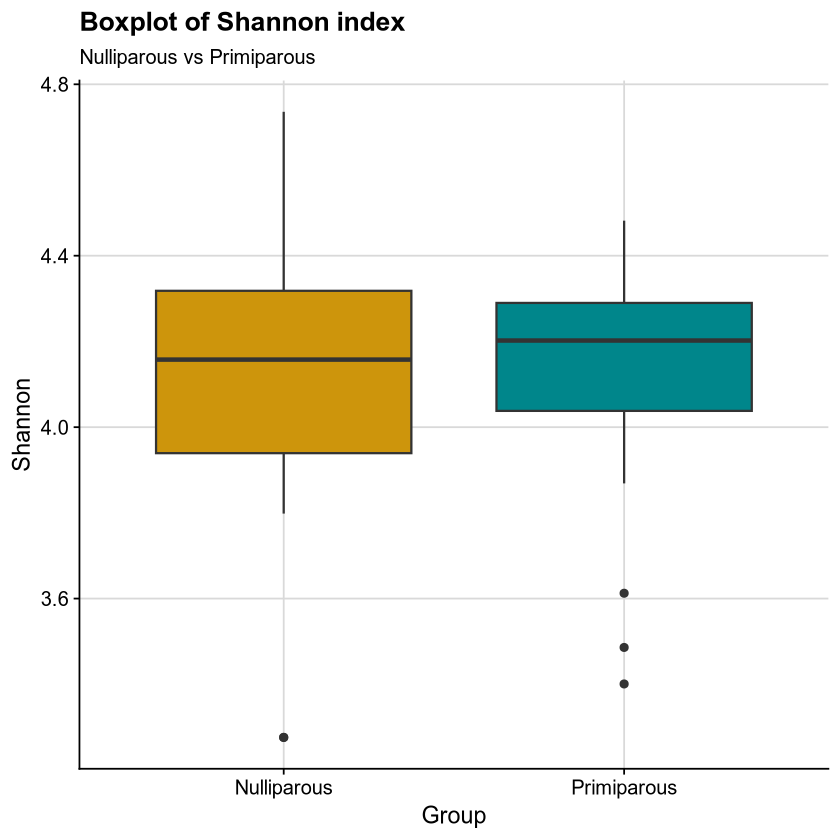

In [81]:
# Choose colors
clr <- c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")

# Boxplot of shannon index
df_shannon |> 
  ggplot(aes(x = Group, y = Shannon, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    title = "Boxplot of Shannon index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Shannon",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

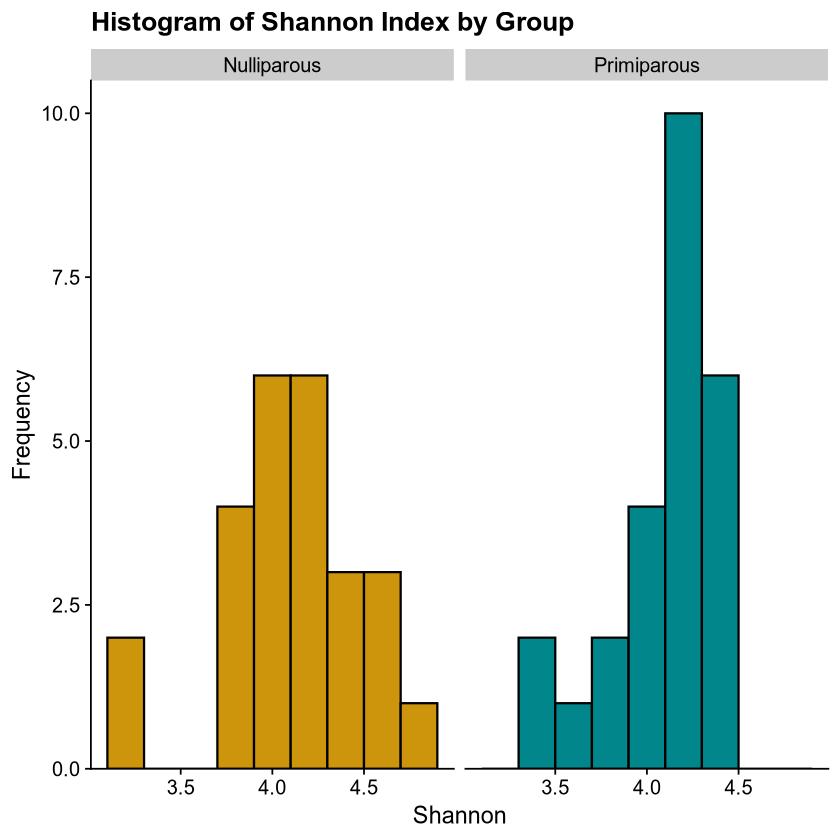

In [82]:
# Histogram of shannon index
df_shannon |> ggplot(aes(x = Shannon, fill = Group)) + 
  geom_histogram(binwidth = 0.2, position = "identity", col = "black") + 
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Shannon Index by Group",
    x = "Shannon",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [83]:
combined_fp_sp_tp1$kit1.faecal_sample.barcode

[1] 100000128343 100000158999 100000101469 100000103241 100000141564
 [6] 100000157404 100000108109 100000101155 100000148624 100000114162
[11] 100000110713 100000102794 100000124499 100000115046 100000136621
[16] 100000116982 100000133514 100000117590 100000112861 100000129906
[21] 100000114025 100000102589 100000101674 100000126486 100000101841
[26] 100000424865 100000422946 100000417676 100000138427 100000417300
[31] 100000419175 100000167687 100000416341 100000419489 100000415924
[36] 100000402412 100000401965 100000410554 100000404683 100000416914
[41] 100000193464 100000410189 100000417447 100000401859 100000422410
[46] 100000429136 100000424421 100000165058 100000401705 100000180006

In [84]:
# after this Primiparous == NA
df_shannon_1 <- df_shannon |>
  rownames_to_column(var = "Sample_ID")
head(df_shannon_1)

,Sample_ID,Shannon,Group
,<chr>,<dbl>,<chr>
1,100000115046,4.517399,Nulliparous
2,100000133514,4.461396,Nulliparous
3,100000141564,4.007270,Nulliparous
4,100000112861,3.939268,Nulliparous
5,100000116982,4.340309,Nulliparous
6,100000117590,4.061135,Nulliparous


In [85]:
df_wide_shan <- pivot_wider(df_shannon_1, names_from = Group, values_from = Shannon)

In [86]:
# Extrac personal numbers for barcodes and add new column with pn to df_shannon_1
pn <- combined_fp_sp_tp1 |>
  filter(kit1.faecal_sample.barcode %in% df_shannon_1$Sample_ID) %>% pull(Q1_Personnummer)
df_shannon_1$Personal_number <- pn
df_shannon_1$Personal_number
head(df_shannon_1)

[1] "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee" "P3cac7b0"
 [7] "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c" "P5b98b6c"
[13] "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[19] "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1" "Pdab1897"
[25] "Pe706703" "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee"
[31] "P3cac7b0" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c"
[37] "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9"
[43] "P9cdfd5a" "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1"
[49] "Pdab1897" "Pe706703"

,Sample_ID,Shannon,Group,Personal_number
,<chr>,<dbl>,<chr>,<chr>
1,100000115046,4.517399,Nulliparous,P159f9c8
2,100000133514,4.461396,Nulliparous,P1a267fa
3,100000141564,4.007270,Nulliparous,P1ef420d
4,100000112861,3.939268,Nulliparous,P1f862a6
5,100000116982,4.340309,Nulliparous,P3c0f6ee
6,100000117590,4.061135,Nulliparous,P3cac7b0


In [87]:
# Write to file, name with no space between
write.csv(df_shannon_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_shannon", ".csv"), row.names = FALSE)

In [88]:
which(duplicated(df_shannon_1$Personal_number) == TRUE)

[1] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50

In [89]:
length(which(duplicated(df_shannon_1$Personal_number) == TRUE))

[1] 25

In [90]:
shannon_wide <- df_shannon_1 |>
  select(Personal_number, Group, Shannon) |>
  pivot_wider(
    names_from = Group,
    values_from = Shannon
    )
shannon_wide

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,4.517399,4.365020
P1a267fa,4.461396,4.282264
P1ef420d,4.007270,4.224153
P1f862a6,3.939268,3.612441
P3c0f6ee,4.340309,4.059124
P3cac7b0,4.061135,4.248299
P3db7da6,3.276238,4.329871
P424fd61,3.861882,3.485983
P4a05456,4.198143,4.257400


In [91]:
shannon_wide$difference <- shannon_wide$Primiparous - shannon_wide$Nulliparous
shapiro.test(shannon_wide$difference)
#shannon_wide$difference


	Shapiro-Wilk normality test

data:  shannon_wide$difference
W = 0.95369, p-value = 0.3031


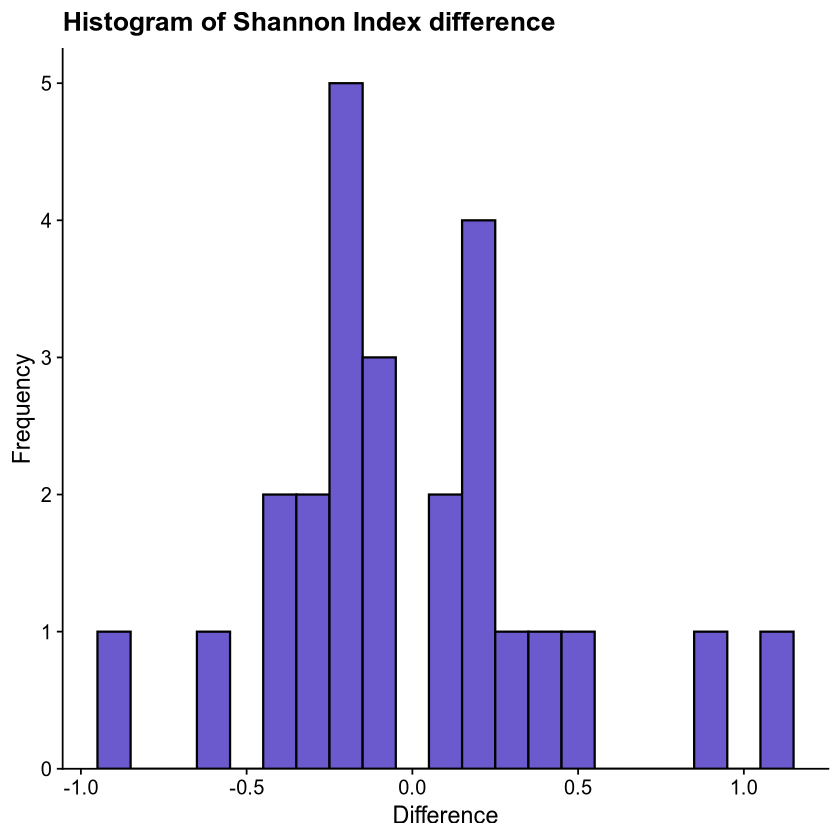

In [92]:
# View the distribution
shannon_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.1, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Shannon Index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [93]:
R.version

               _                           
platform       x86_64-conda-linux-gnu      
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          5.2                         
year           2025                        
month          10                          
day            31                          
svn rev        88974                       
language       R                           
version.string R version 4.5.2 (2025-10-31)
nickname       [Not] Part in a Rumble      

In [94]:
t.test(Pair(Nulliparous, Primiparous) ~ 1,data = shannon_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = -0.050001, df = 24, p-value = 0.9605
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -0.1826880  0.1740457
sample estimates:
mean difference 
    -0.00432116 


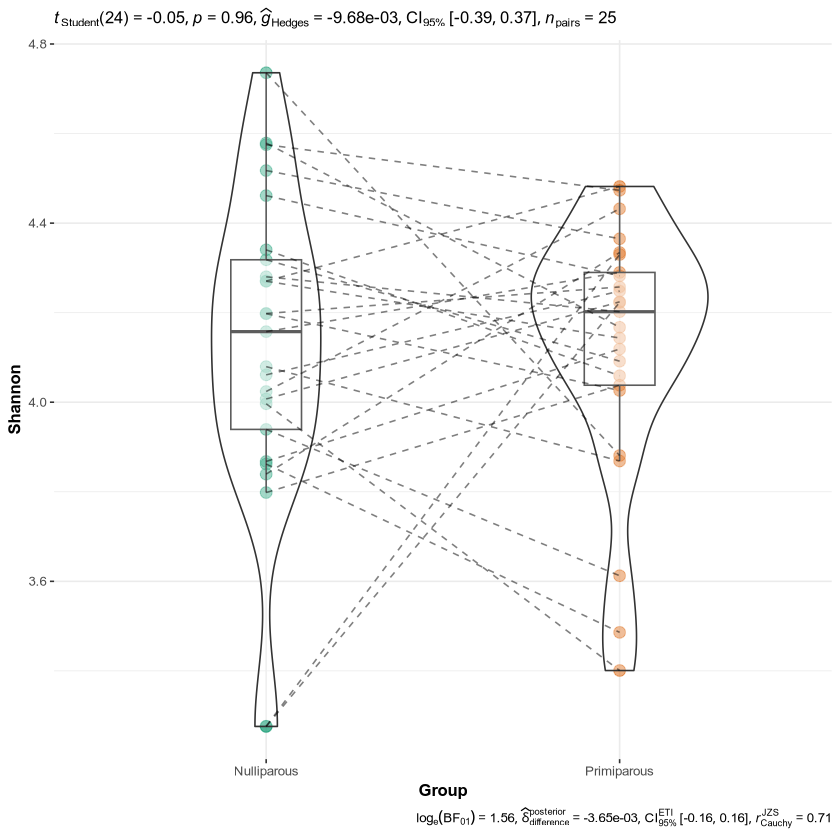

In [95]:
ggwithinstats( # paired samples
  data = df_shannon_1,
  x = Group,
  y = Shannon,
  centrality.plotting = FALSE # remove median
)

In [105]:
# Shannon Diversity Index Plot
plot_shan <- ggplot(df_shannon, aes(x = Group, y = Shannon, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(title = "(A) Shannon Diversity Index", x = "Group", y = "Shannon Index") +
  geom_bracket(
    xmin = "", xmax = "1", y.position = 3, label = "ns") +
  theme_half_open() +
  background_grid() +
 # geom_text(x = 1.45, y = 5.05, label = "ns", color = "gray20", fontface
           # = "plain", hjust = 0) +
  #geom_segment(aes(x = 1, xend = 2, y = 5, yend = 5), color = "black", linewidth
              # = 0.4) +
  theme(legend.position = "none") 
plot_shan

ERROR while rich displaying an object: Error in `geom_bracket()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 3rd layer.
Caused by error:
! object 'Group' not found

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 

## Species richness--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [116]:
# 2 for columns, column = sample
fp_sr <- apply(fp_taxa, 2, specnumber)
head(fp_sr)

100000115046 100000133514 100000141564 100000112861 100000116982 100000117590 
         406          416          304          336          385          380

In [117]:
sp_sr <- apply(sp_taxa, 2, specnumber)
head(sp_sr)

100000138427 100000416914 100000416341 100000417300 100000415924 100000417676 
         359          373          352          306          250          393

In [118]:
summary(fp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  161.0   312.0   340.0   337.3   385.0   439.0 

In [119]:
summary(sp_sr)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  158.0   272.0   341.0   320.1   373.0   424.0 

In [120]:
# New df including richness
df_richness <-  data.frame(Species_richness = c(fp_sr, sp_sr), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_sr), length(sp_sr))))
head(df_richness)

,Species_richness,Group
,<int>,<chr>
100000115046,406,Nulliparous
100000133514,416,Nulliparous
100000141564,304,Nulliparous
100000112861,336,Nulliparous
100000116982,385,Nulliparous
100000117590,380,Nulliparous


In [121]:
# Check that num of participants correct
df_richness |> filter(Group == "Nulliparous") |> count()

n
<int>
25


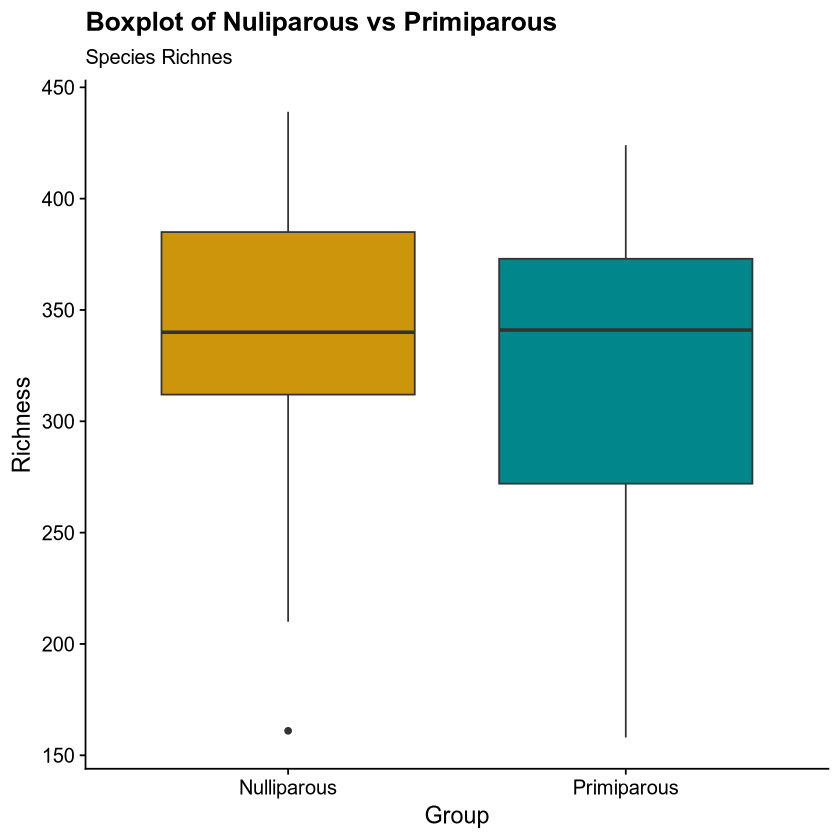

In [122]:
# Boxplot of species richness
df_richness |>
  ggplot(aes(x = Group, y = Species_richness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Richness",
    title = "Boxplot of Nuliparous vs Primiparous",
    subtitle = "Species Richnes"
  ) +
  theme_half_open() +
  theme(legend.position = "none") 

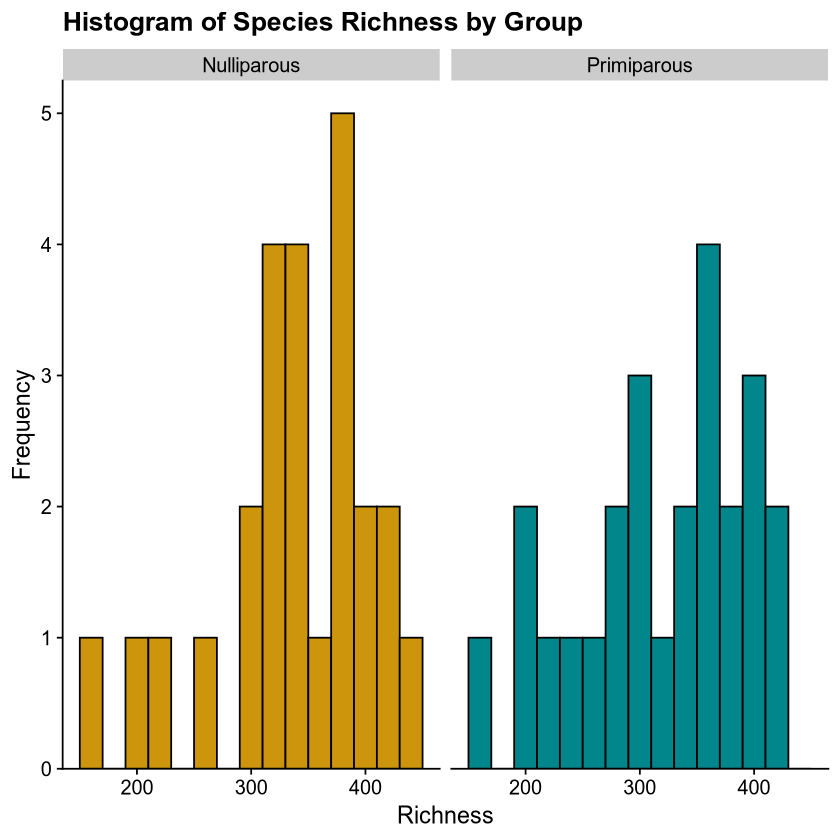

In [123]:
# Histogram of species richness
df_richness |> ggplot(aes(x = Species_richness, fill = Group)) +
  geom_histogram(binwidth = 20, position = "identity", col = "black") +
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Species Richness by Group",
    x = "Richness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 


In [124]:
# Calculate difference for Shapiro test
df_richness_1 <- df_richness |>
  rownames_to_column(var = "Sample_ID")
df_richness_1

Sample_ID,Species_richness,Group
<chr>,<int>,<chr>
100000115046,406,Nulliparous
100000133514,416,Nulliparous
100000141564,304,Nulliparous
100000112861,336,Nulliparous
100000116982,385,Nulliparous
100000117590,380,Nulliparous
100000126486,161,Nulliparous
100000114162,210,Nulliparous
100000110713,326,Nulliparous


In [125]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_richness <- combined_fp_sp_tp1 |>
  filter(kit1.faecal_sample.barcode %in% df_richness_1$Sample_ID) %>% pull(Q1_Personnummer)

In [126]:
# Add column with pn
df_richness_1$Personal_number <- pn_richness
df_richness_1$Personal_number

[1] "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee" "P3cac7b0"
 [7] "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c" "P5b98b6c"
[13] "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[19] "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1" "Pdab1897"
[25] "Pe706703" "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee"
[31] "P3cac7b0" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c"
[37] "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9"
[43] "P9cdfd5a" "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1"
[49] "Pdab1897" "Pe706703"

In [127]:
length(df_richness_1$Personal_number)
head(df_richness_1)

[1] 50

,Sample_ID,Species_richness,Group,Personal_number
,<chr>,<int>,<chr>,<chr>
1,100000115046,406,Nulliparous,P159f9c8
2,100000133514,416,Nulliparous,P1a267fa
3,100000141564,304,Nulliparous,P1ef420d
4,100000112861,336,Nulliparous,P1f862a6
5,100000116982,385,Nulliparous,P3c0f6ee
6,100000117590,380,Nulliparous,P3cac7b0


In [128]:
which(duplicated(df_richness_1$Personal_number) == TRUE)

[1] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50

In [129]:
length(which(duplicated(df_richness_1$Personal_number) == TRUE))

[1] 25

In [130]:
write.csv(df_richness_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_richness", ".csv"), row.names = FALSE)

In [131]:
richness_wide <- df_richness_1 |>
  select(Personal_number, Group, Species_richness) |>
  pivot_wider(
             names_from = Group,
             values_from = Species_richness
           )

In [132]:
# Test data distribution
richness_wide$difference <- richness_wide$Primiparous - richness_wide$Nulliparous
shapiro.test(richness_wide$difference)


	Shapiro-Wilk normality test

data:  richness_wide$difference
W = 0.97079, p-value = 0.6651


In [133]:
head(richness_wide)

Personal_number,Nulliparous,Primiparous,difference
<chr>,<int>,<int>,<int>
P159f9c8,406,359,-47
P1a267fa,416,373,-43
P1ef420d,304,352,48
P1f862a6,336,306,-30
P3c0f6ee,385,250,-135
P3cac7b0,380,393,13


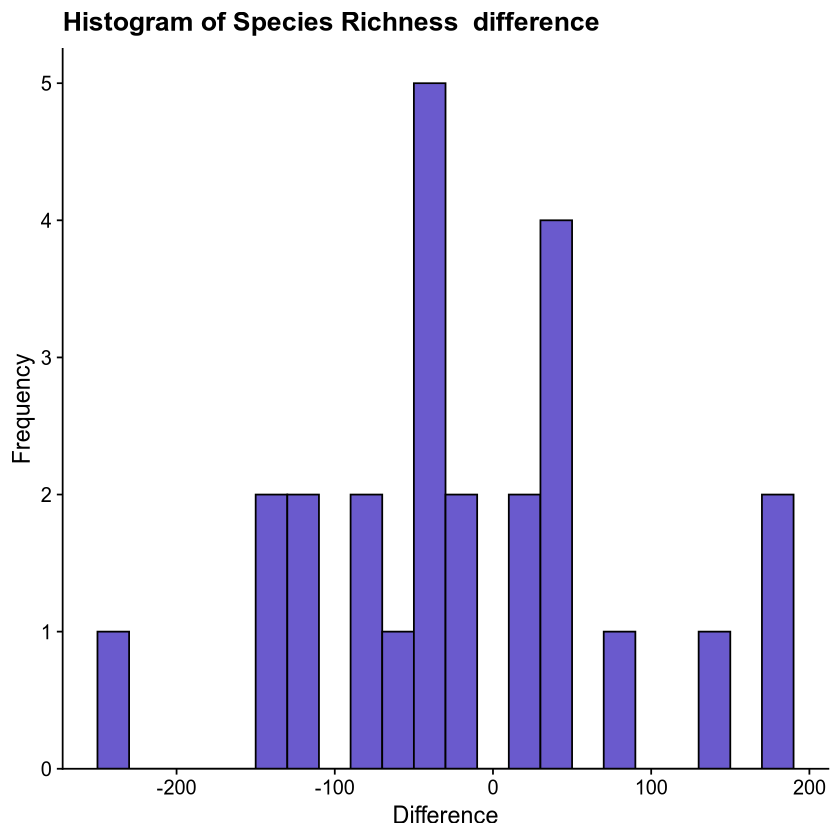

In [134]:
# Data distribution visualization
richness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 20, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Richness  difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [135]:
t.test(Pair(Nulliparous, Primiparous) ~ 1, data = richness_wide)


	Paired t-test

data:  Pair(Nulliparous, Primiparous)
t = 0.84462, df = 24, p-value = 0.4067
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -24.82944  59.22944
sample estimates:
mean difference 
           17.2 


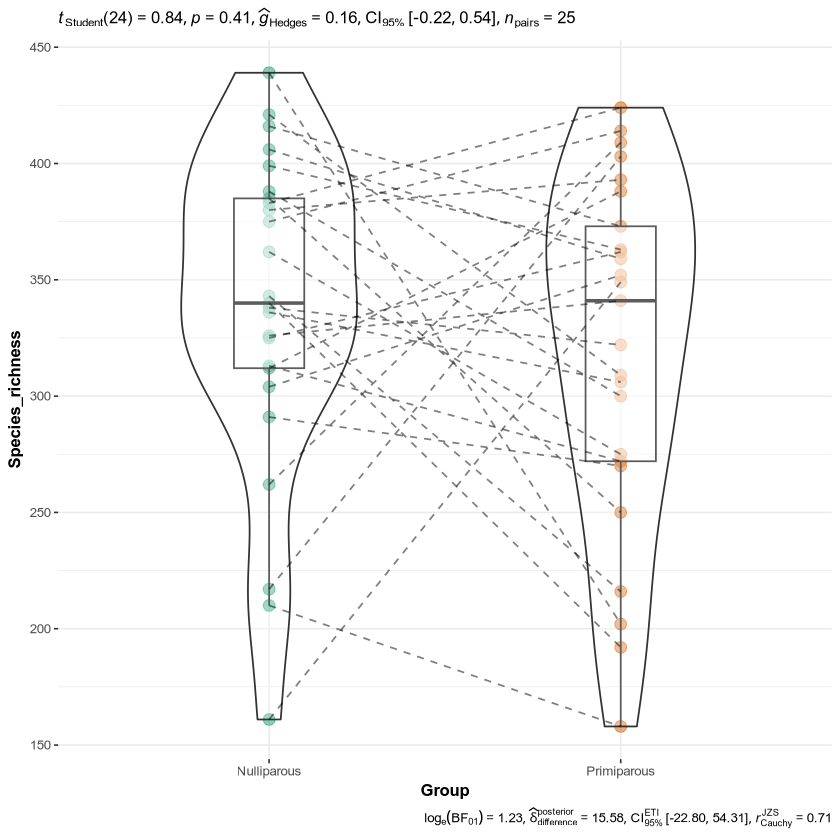

In [136]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_richness,
  x = Group,
  y = Species_richness,
  centrality.plotting = FALSE # remove median
)

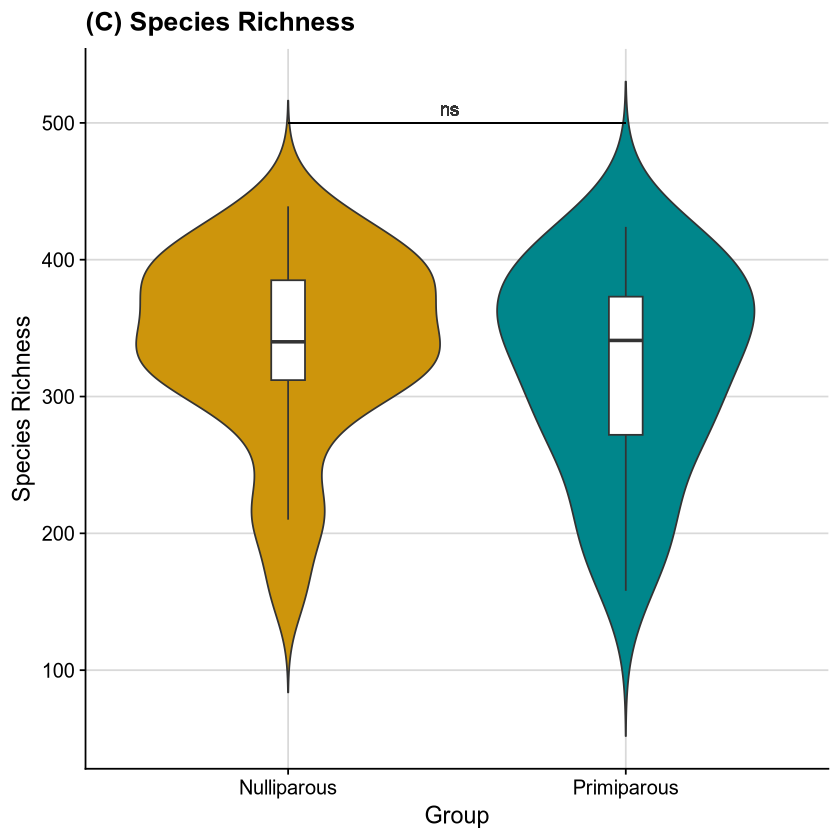

In [181]:
# Shannon Diversity Index Plot
plot_richness <- ggplot(df_richness, aes(x = Group, y = Species_richness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    title = "(C) Species Richness", 
    x = "Group", 
    y = "Species Richness"
    ) +
  theme_half_open() +
  background_grid() +
  geom_text(x = 1.45, y = 510, label = "ns", color = "gray20", fontface
            = "plain", hjust = 0) +
  geom_segment(aes(x = 1, xend = 2, y = 500, yend = 500), color = "black", linewidth
               = 0.4) +
  theme(legend.position = "none") 
plot_richness

## Evenness ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [138]:
# Fp
case_pie_small <- fp_shan/log(fp_sr)
case_pie_small

100000115046 100000133514 100000141564 100000112861 100000116982 100000117590 
   0.7521035    0.7397825    0.7009359    0.6771863    0.7290663    0.6836731 
100000126486 100000114162 100000110713 100000108109 100000103241 100000101469 
   0.6447505    0.7222376    0.7254566    0.7448578    0.7645408    0.7066895 
100000157404 100000128343 100000101674 100000101155 100000102589 100000114025 
   0.6694899    0.6488368    0.7188347    0.7179863    0.5704094    0.6987995 
100000158999 100000101841 100000148624 100000102794 100000129906 100000136621 
   0.7226413    0.7136605    0.7719227    0.6856371    0.7329264    0.7208845 
100000124499 
   0.7783343

In [139]:
summary(case_pie_small)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.5704  0.6856  0.7188  0.7097  0.7329  0.7783 

In [140]:
# Sp
control_pie <- sp_shan/log(sp_sr)
control_pie

100000138427 100000416914 100000416341 100000417300 100000415924 100000417676 
   0.7419310    0.7231626    0.7203988    0.6311500    0.7351540    0.7111540 
100000402412 100000401705 100000401859 100000424865 100000193464 100000419489 
   0.7395077    0.6885763    0.7300216    0.7496013    0.7070047    0.7226932 
100000429136 100000417447 100000401965 100000404683 100000410189 100000180006 
   0.7212663    0.7221083    0.7281252    0.7408302    0.7084111    0.7197168 
100000410554 100000422410 100000424421 100000167687 100000422946 100000165058 
   0.7369784    0.7225171    0.7423338    0.6468434    0.7284633    0.6972235 
100000419175 
   0.7311052

In [141]:
summary(control_pie)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.6311  0.7112  0.7227  0.7179  0.7352  0.7496 

In [142]:
df_evenness <-  data.frame(Evenness = c(case_pie_small, control_pie), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(case_pie_small), length(control_pie))))
head(df_evenness)
class(df_evenness$Evenness)

,Evenness,Group
,<dbl>,<chr>
100000115046,0.7521035,Nulliparous
100000133514,0.7397825,Nulliparous
100000141564,0.7009359,Nulliparous
100000112861,0.6771863,Nulliparous
100000116982,0.7290663,Nulliparous
100000117590,0.6836731,Nulliparous


[1] "numeric"

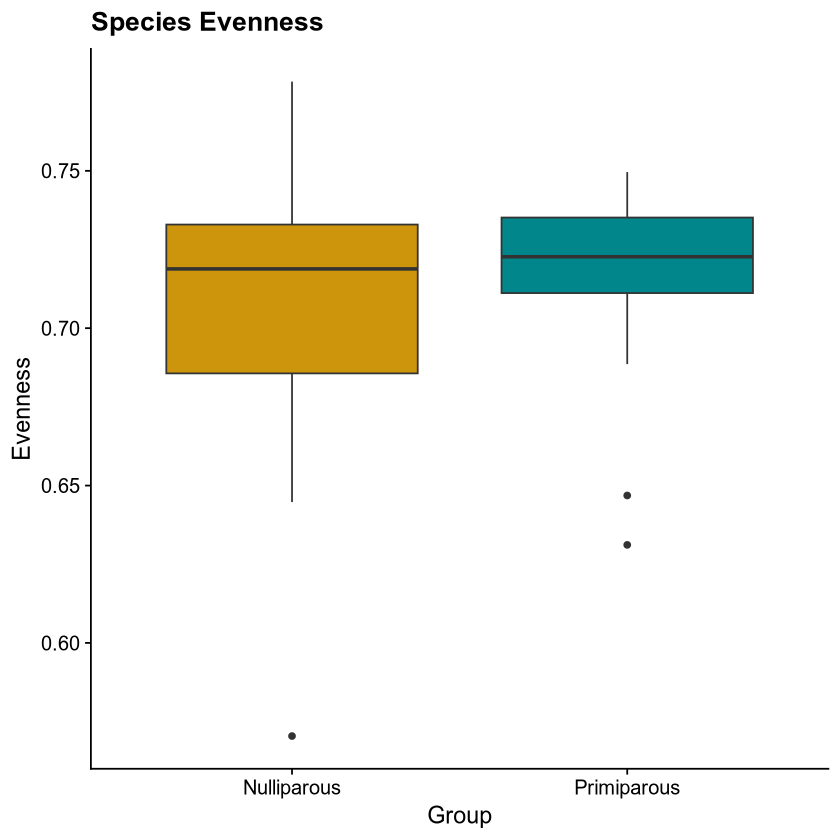

In [143]:
# Boxplot of evenness
df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Evenness",
    title = "Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none")

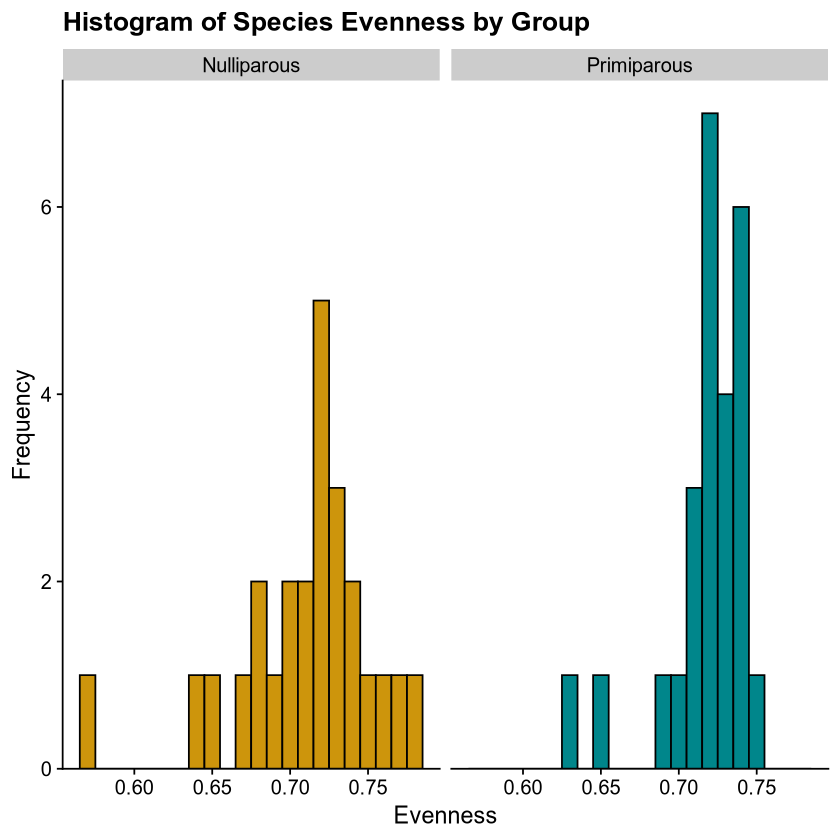

In [144]:
# Histogram of evenness
df_evenness |> ggplot(aes(x = Evenness, fill = Group)) + 
  geom_histogram(binwidth = 0.01, position = "identity", col = "black") + 
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Species Evenness by Group",
    x = "Evenness",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 


In [145]:
df_evenness <- df_evenness |>
  rownames_to_column(var = "Sample_ID")
df_evenness

Sample_ID,Evenness,Group
<chr>,<dbl>,<chr>
100000115046,0.7521035,Nulliparous
100000133514,0.7397825,Nulliparous
100000141564,0.7009359,Nulliparous
100000112861,0.6771863,Nulliparous
100000116982,0.7290663,Nulliparous
100000117590,0.6836731,Nulliparous
100000126486,0.6447505,Nulliparous
100000114162,0.7222376,Nulliparous
100000110713,0.7254566,Nulliparous


In [146]:
# Find and extract pn
pn_evenness <- combined_fp_sp_tp1 |>
  filter(kit1.faecal_sample.barcode %in% df_evenness$Sample_ID) |> pull(Q1_Personnummer)
pn_evenness

[1] "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee" "P3cac7b0"
 [7] "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c" "P5b98b6c"
[13] "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[19] "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1" "Pdab1897"
[25] "Pe706703" "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee"
[31] "P3cac7b0" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c"
[37] "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9"
[43] "P9cdfd5a" "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1"
[49] "Pdab1897" "Pe706703"

In [147]:
df_evenness$Personal_number <- pn_evenness
df_evenness

Sample_ID,Evenness,Group,Personal_number
<chr>,<dbl>,<chr>,<chr>
100000115046,0.7521035,Nulliparous,P159f9c8
100000133514,0.7397825,Nulliparous,P1a267fa
100000141564,0.7009359,Nulliparous,P1ef420d
100000112861,0.6771863,Nulliparous,P1f862a6
100000116982,0.7290663,Nulliparous,P3c0f6ee
100000117590,0.6836731,Nulliparous,P3cac7b0
100000126486,0.6447505,Nulliparous,P3db7da6
100000114162,0.7222376,Nulliparous,P424fd61
100000110713,0.7254566,Nulliparous,P4a05456


In [148]:
write.csv(df_evenness, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_evenness", ".csv"), row.names = FALSE)

In [149]:
evenness_wide <- df_evenness |>
  select(Personal_number, Group, Evenness) |>
  pivot_wider(
    names_from = Group,
    values_from = Evenness
  )
evenness_wide

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.7521035,0.7419310
P1a267fa,0.7397825,0.7231626
P1ef420d,0.7009359,0.7203988
P1f862a6,0.6771863,0.6311500
P3c0f6ee,0.7290663,0.7351540
P3cac7b0,0.6836731,0.7111540
P3db7da6,0.6447505,0.7395077
P424fd61,0.7222376,0.6885763
P4a05456,0.7254566,0.7300216


In [150]:
evenness_wide$difference <- evenness_wide$Primiparous - evenness_wide$Nulliparous
shapiro.test(evenness_wide$difference)


	Shapiro-Wilk normality test

data:  evenness_wide$difference
W = 0.91712, p-value = 0.04406


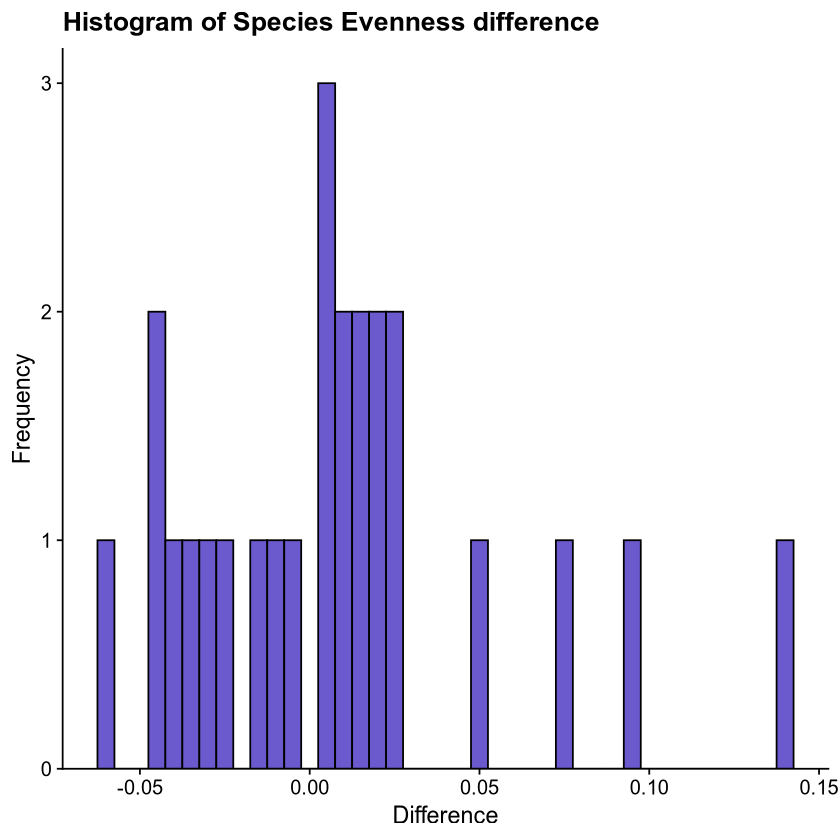

In [151]:
# Visualize data distribution
evenness_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.005, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Species Evenness difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

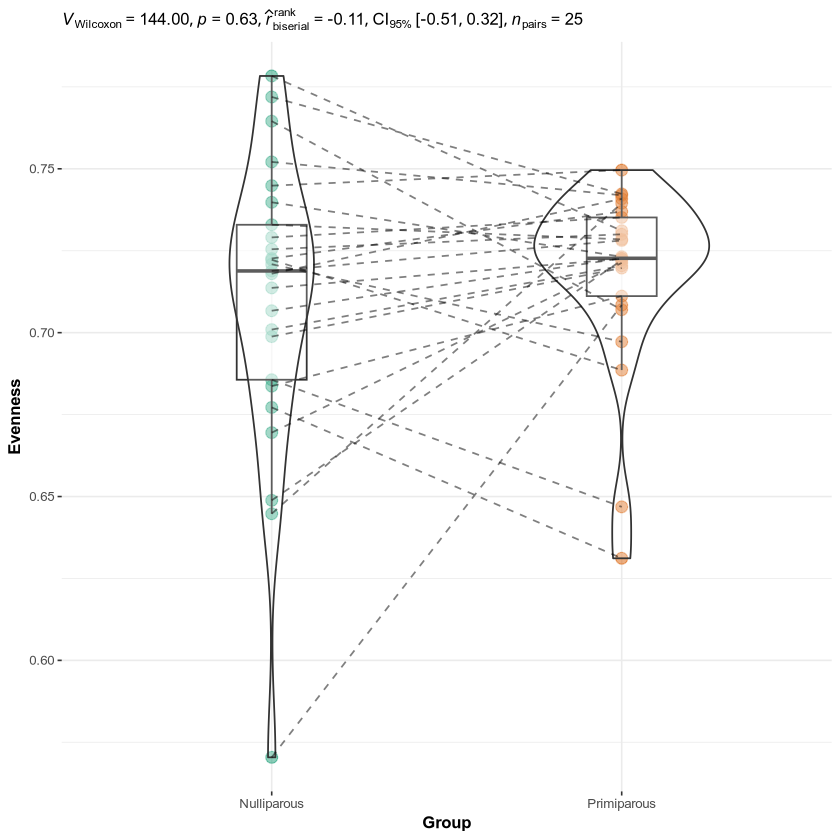

In [152]:
# view the data distribution
# plot with statistical results
ggwithinstats( # paired samples
  data = df_evenness,
  x = Group,
  y = Evenness,
  type = "nonparametric", # for wilcoxon
  centrality.plotting = FALSE # remove median
)

In [153]:
test_evenness <- wilcox.test(Pair(Nulliparous, Primiparous) ~1, data = evenness_wide)
test_evenness


	Wilcoxon signed rank exact test

data:  Pair(Nulliparous, Primiparous)
V = 144, p-value = 0.6338
alternative hypothesis: true location shift is not equal to 0


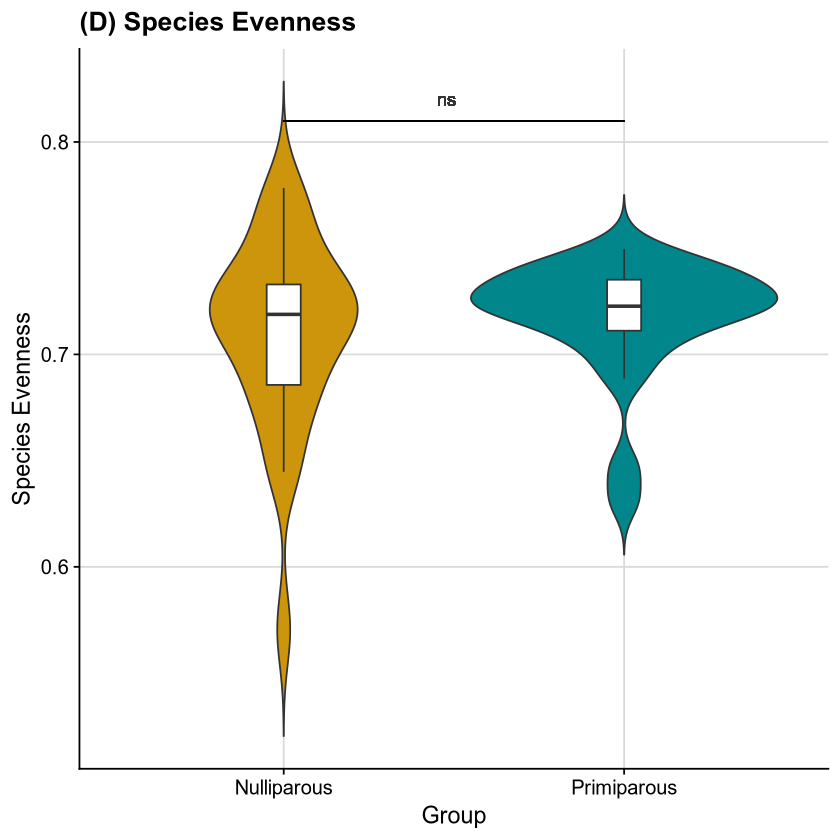

In [198]:
# Violin plots of evenness
plot_evenness <- df_evenness |> ggplot(aes(x = Group, y = Evenness, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Species Evenness",
    title = "(D) Species Evenness"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  geom_text(x = 1.45, y = 0.82, label = "ns", color = "gray20", fontface
            = "plain", hjust = 0) +
  geom_segment(aes(x = 1, xend = 2, y = 0.81, yend = 0.81), color = "black", linewidth
               = 0.4) +
  theme(legend.position = "none") 
plot_evenness

## Simpson's index---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [155]:
# 2 for columns, column = sample
fp_simpson <- apply(fp_taxa, 2, diversity, index = "simpson")
head(fp_simpson)

100000115046 100000133514 100000141564 100000112861 100000116982 100000117590 
   0.9728134    0.9776683    0.9603047    0.9623793    0.9773755    0.9598332

In [156]:
sp_simpson <- apply(sp_taxa, 2, diversity, index = "simpson")
head(fp_simpson)

100000115046 100000133514 100000141564 100000112861 100000116982 100000117590 
   0.9728134    0.9776683    0.9603047    0.9623793    0.9773755    0.9598332

In [157]:
df_simpson <-  data.frame(Simpson = c(fp_simpson, sp_simpson), Group = rep(c("Nulliparous", "Primiparous"), times = c(length(fp_simpson), length(sp_simpson))))
head(df_simpson)
class(df_simpson$Simpson)

,Simpson,Group
,<dbl>,<chr>
100000115046,0.9728134,Nulliparous
100000133514,0.9776683,Nulliparous
100000141564,0.9603047,Nulliparous
100000112861,0.9623793,Nulliparous
100000116982,0.9773755,Nulliparous
100000117590,0.9598332,Nulliparous


[1] "numeric"

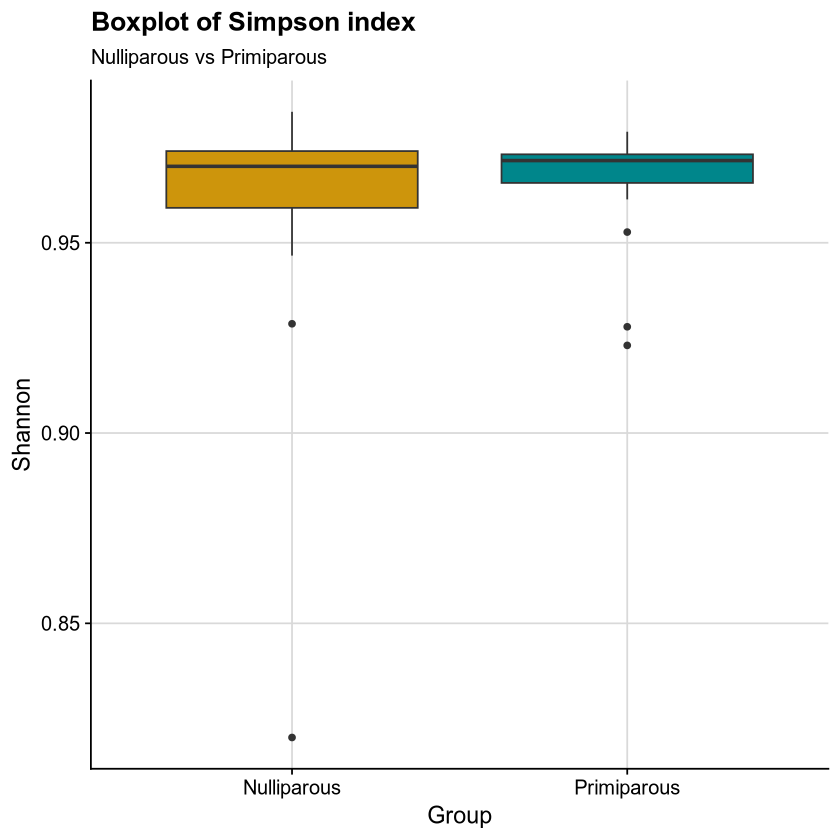

In [158]:
# Boxplot of Simpson index
df_simpson |> 
  ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_boxplot() +
  scale_fill_manual(values = clr) +
  labs(
    title = "Boxplot of Simpson index",
      subtitle = "Nulliparous vs Primiparous",
    x = "Group",
    y = "Shannon",
  ) +
  theme_half_open() +
  background_grid() +
  theme(legend.position = "none")

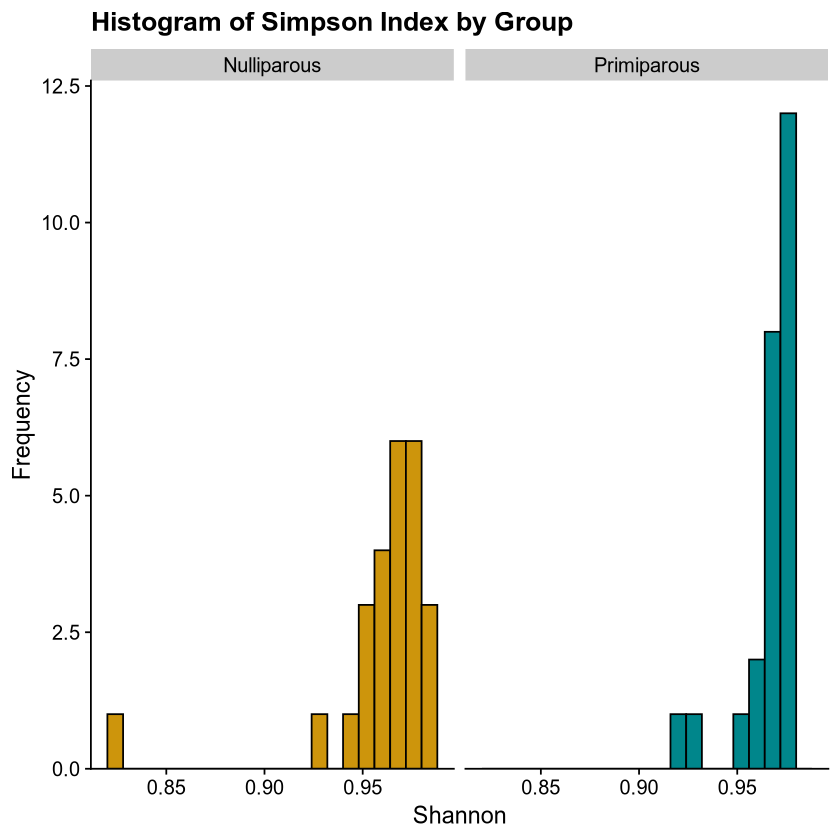

In [159]:
# Histogram of simpson index
df_simpson |> ggplot(aes(x = Simpson, fill = Group)) + 
  geom_histogram(binwidth = 0.008, position = "identity", col = "black") + 
  scale_fill_manual(values = c("Nulliparous" = "darkgoldenrod3", "Primiparous" = "turquoise4")) +
  labs(
    title = "Histogram of Simpson Index by Group",
    x = "Shannon",
    y = "Frequency"# Histogram of shannon index
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open() +
  facet_wrap(~Group) +
  theme(legend.position = "none") 

In [160]:
df_simpson_1 <- df_simpson |>
  rownames_to_column(var = "Sample_ID")
head(df_simpson_1)

,Sample_ID,Simpson,Group
,<chr>,<dbl>,<chr>
1,100000115046,0.9728134,Nulliparous
2,100000133514,0.9776683,Nulliparous
3,100000141564,0.9603047,Nulliparous
4,100000112861,0.9623793,Nulliparous
5,100000116982,0.9773755,Nulliparous
6,100000117590,0.9598332,Nulliparous


In [161]:
# Extrac personal numbers for barcodes and add new column with pn to df_richness_1
pn_simpson<- combined_fp_sp_tp1 |>
  filter(kit1.faecal_sample.barcode %in% df_simpson_1$Sample_ID) %>% pull(Q1_Personnummer)
# Add column with pn
df_simpson_1$Personal_number <- pn_simpson
df_simpson_1$Personal_number

[1] "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee" "P3cac7b0"
 [7] "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c" "P5b98b6c"
[13] "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9" "P9cdfd5a"
[19] "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1" "Pdab1897"
[25] "Pe706703" "P159f9c8" "P1a267fa" "P1ef420d" "P1f862a6" "P3c0f6ee"
[31] "P3cac7b0" "P3db7da6" "P424fd61" "P4a05456" "P4de45e7" "P50f102c"
[37] "P5b98b6c" "P62ea0b2" "P719b21e" "P7ece52e" "P92b4604" "P97574f9"
[43] "P9cdfd5a" "Pa8f3b51" "Pbe289c8" "Pc44e366" "Pc77a35c" "Pcd2c0d1"
[49] "Pdab1897" "Pe706703"

In [162]:
length(which(duplicated(df_simpson_1$Personal_number) == TRUE))

[1] 25

In [165]:
write.csv(df_simpson_1, file = paste0( "/ceph/projects/010_SweMaMi//bm.nowak/filtered_data/feacal/tp1_nulliparous/tp1_alpha_beta_diversity/alpha/", Sys.Date(), "_tp1_simpson", ".csv"), row.names = FALSE)

In [166]:
simpson_wide <- df_simpson_1 |>
  select(Personal_number, Group, Simpson) |>
  pivot_wider(
             names_from = Group,
             values_from = Simpson
           )
head(simpson_wide)

Personal_number,Nulliparous,Primiparous
<chr>,<dbl>,<dbl>
P159f9c8,0.9728134,0.9757311
P1a267fa,0.9776683,0.9727181
P1ef420d,0.9603047,0.9715936
P1f862a6,0.9623793,0.9279241
P3c0f6ee,0.9773755,0.9722913
P3cac7b0,0.9598332,0.9725083


In [167]:
# Test data distribution
simpson_wide$difference <- simpson_wide$Primiparous - simpson_wide$Nulliparous
shapiro.test(simpson_wide$difference)


	Shapiro-Wilk normality test

data:  simpson_wide$difference
W = 0.64675, p-value = 1.513e-06


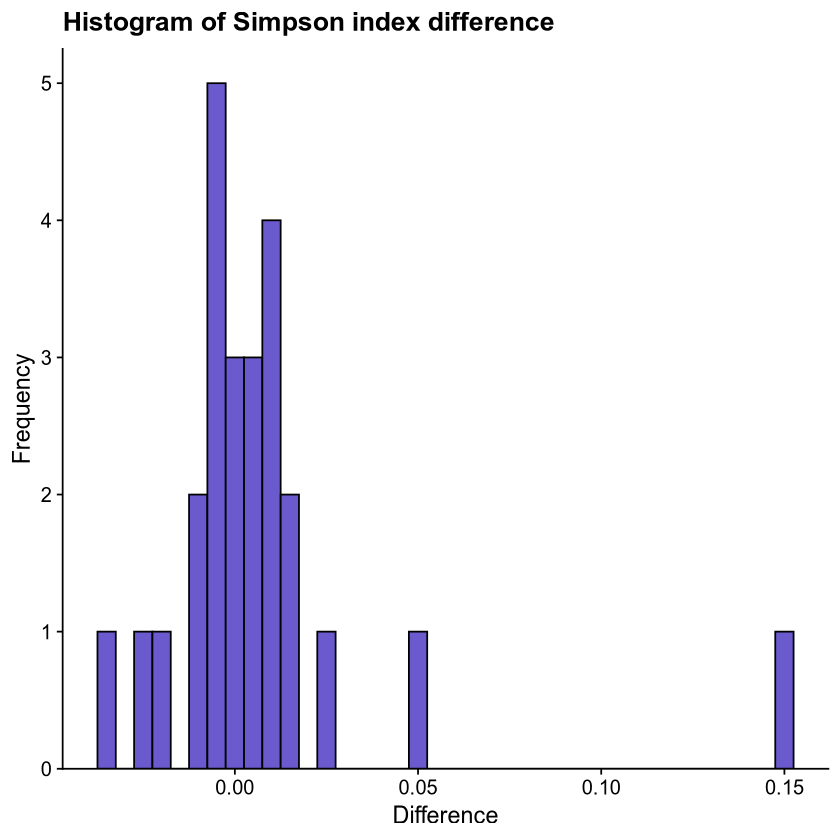

In [168]:
# Data distribution visualization
simpson_wide |> ggplot(aes(x = difference)) + 
  geom_histogram(binwidth = 0.005, position = "identity", fill = "slateblue", col = "black") + 
  labs(
    title = "Histogram of Simpson index difference",
    x = "Difference",
    y = "Frequency"
  ) + 
  scale_y_continuous(
    # Don't expand y scale at the lower end
    expand = expansion(mult = c(0, 0.05))
  ) +
  theme_half_open()

In [169]:
test_simpson <- wilcox.test(Pair(Nulliparous, Primiparous) ~1, data = simpson_wide)
test_simpson


	Wilcoxon signed rank exact test

data:  Pair(Nulliparous, Primiparous)
V = 139, p-value = 0.5424
alternative hypothesis: true location shift is not equal to 0


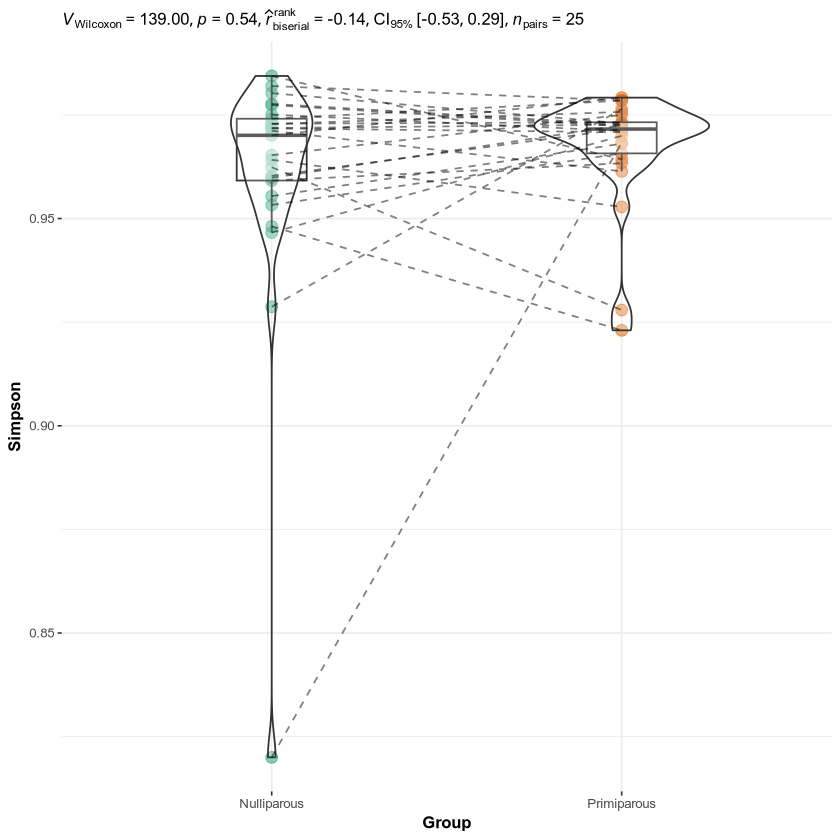

In [170]:
# view the data distribution
ggwithinstats( # paired samples
  data = df_simpson,
  x = Group,
  y = Simpson,
  type = "nonparametric", # for wilcoxon
  centrality.plotting = FALSE # remove median
)

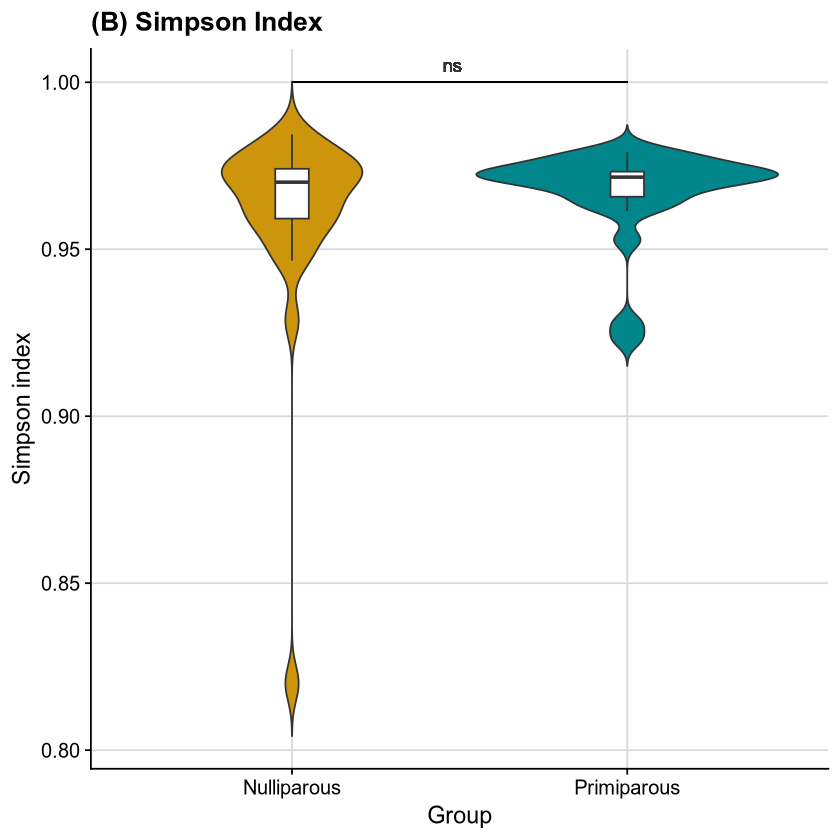

In [196]:
# Violin plots
plot_simpson <- df_simpson |> ggplot(aes(x = Group, y = Simpson, fill = Group)) +
  geom_violin(trim = FALSE) + 
  geom_boxplot(width = 0.1, fill = "white", outlier.shape = NA) +
  scale_fill_manual(values = clr) +
  labs(
    x = "Group",
    y = "Simpson index",
    title = "(B) Simpson Index"
  ) +
  theme_half_open() +
  theme(legend.position = "none") +
  background_grid() +
  geom_text(x = 1.45, y = 1.005, label = "ns", color = "gray20", fontface
            = "plain", hjust = 0) +
  geom_segment(aes(x = 1, xend = 2, y = 1, yend = 1), color = "black", linewidth
               = 0.4) +
  theme(legend.position = "none") 
plot_simpson

# Combined plot~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

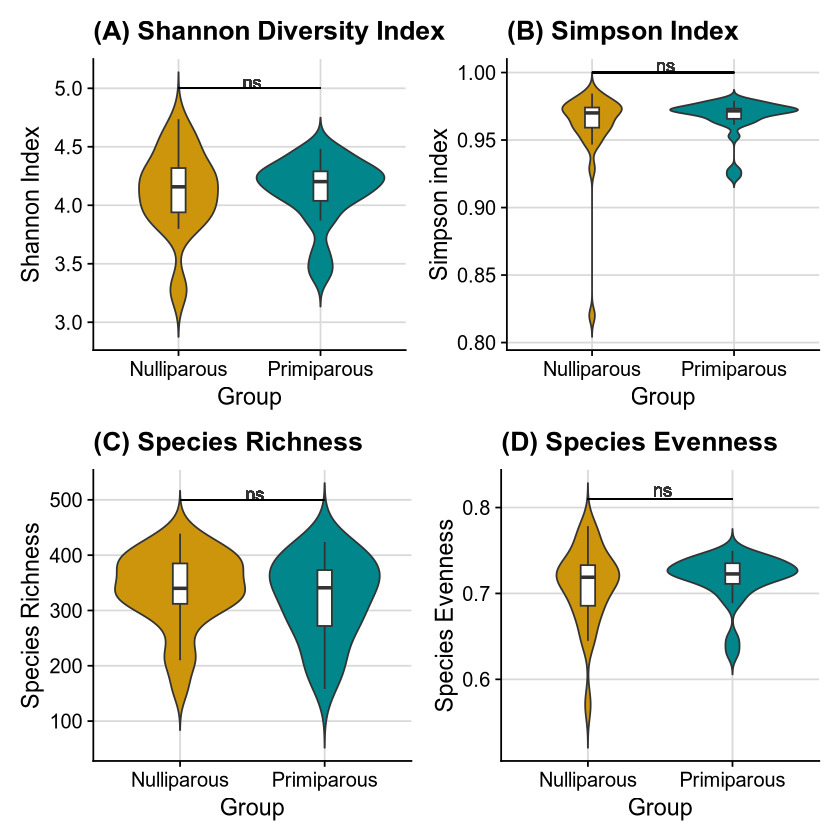

In [200]:
(plot_shan | plot_simpson) / (plot_richness | plot_evenness) 
#gg_remove_titl
#theme(axis.title.x = element_blank(), axis.text.x = element_blank())
#theme( legend.position = "bottom")
